In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno as msno

In [2]:
df = pd.read_csv("/Users/prerana/Documents/Banking_case/Banking_clean.csv")

In [3]:
df.head(5)

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [5]:
product_cols = [
    "Superannuation Savings",
    "Bank Loans",
    "Bank Deposits",
    "Business Lending",
    "Foreign Currency Account",
    "Saving Accounts",
    "Checking Accounts"
]

df["Product_Count"] = df[product_cols].apply(lambda x: x.gt(0).sum(), axis=1)

In [13]:
# Total financial assets a customer holds
df["Total_Financial_Value"] = (
    df["Superannuation Savings"] +
    df["Bank Deposits"] +
    df["Saving Accounts"] +
    df["Checking Accounts"] +
    df["Foreign Currency Account"] +
    df["Business Lending"] +
    df["Bank Loans"]
)

# Combine income + assets into one value metric
df["Customer_Value"] = df["Estimated Income"] + df["Total_Financial_Value"]

#RFM-Style Engagement Matrix

# Convert "Joined Bank" to datetime
df["Joined Bank"] = pd.to_datetime(df["Joined Bank"], errors="coerce")

# Calculate recency as "years since joining"
today = pd.to_datetime("today")
df["Recency_Years"] = ((today - df["Joined Bank"]).dt.days) / 365

rfm_product_cols = [
    "Superannuation Savings",
    "Bank Loans",
    "Bank Deposits",
    "Checking Accounts",
    "Saving Accounts",
    "Foreign Currency Account",
    "Business Lending"
]
# F: Frequency
# Count number of products actively used
df["Frequency"] = df[rfm_product_cols].gt(0).sum(axis=1)

#  M: Monetary
df["Monetary"] = df["Estimated Income"]


In [21]:
#Filling missing NaN with median
df.isnull().sum().sort_values(ascending=False)
#Numerical:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
#Categorical:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [56]:
#Churn Label
# Create churn score

df["Churn_Score"] = 0

# Low frequency
df.loc[
    df["Frequency"] < df["Frequency"].median(),
    "Churn_Score"
] += 1

# Low monetary value
df.loc[
    df["Monetary"] < df["Monetary"].median(),
    "Churn_Score"
] += 1

# High recency
df.loc[
    df["Recency_Years"] > df["Recency_Years"].median(),
    "Churn_Score"
] += 1

# Low product ownership
df.loc[
    df["Product_Count"] <= 2,
    "Churn_Score"
] += 1

df["Churn"] = np.where(
    df["Churn_Score"] >= 2,
    1,
    0
)

print(df["Churn"].value_counts())

Churn
0    2665
1     335
Name: count, dtype: int64


In [57]:
X = df_encoded.drop(
    columns=[
        "Churn",
        "Churn_Score",
        "Name",
        "Client ID",
        "Joined Bank"
    ],
    errors="ignore"
)

y = df["Churn"]

In [58]:
#Feature Engineering
#Product Diversification

df["Product_Diversity"] = (
    df["Product_Count"] / 7
)

#Debt-To-Income Ratio

df["Debt_Income_Ratio"] = (
    df["Bank Loans"] / (df["Estimated Income"] + 1)
)

#Credit Utilisation Ratio
df["Credit_Utilization"] = (
    df["Credit Card Balance"] /
    (df["Amount of Credit Cards"] + 1)
)

# Customer Tenure
df["Joined Bank"] = pd.to_datetime(
    df["Joined Bank"],
    errors="coerce"
)

current_year = 2026

df["Tenure"] = (
    current_year - df["Joined Bank"].dt.year
)
df["Tenure"] = df["Tenure"].fillna(
    df["Tenure"].median()
)

print(df["Tenure"].head())

#High net worth flag
df["High_Value_Customer"] = np.where(
    df["Customer_Value"] >
    df["Customer_Value"].quantile(0.75),
    1,
    0
)

0     7.0
1    25.0
2    15.0
3    15.0
4    15.0
Name: Tenure, dtype: float64


In [59]:
#Data Preprocessing
features = [
    'Age',
    'GenderId',
    'Estimated Income',
    'Bank Loans',
    'Bank Deposits',
    'Checking Accounts',
    'Saving Accounts',
    'Business Lending',
    'Risk Weighting',
    'Product_Count',
    'Customer_Value',
    'Debt_Income_Ratio',
    'Credit_Utilization',
    'Tenure'
]

X = df[features]
y = df["Churn"]

In [60]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [61]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)


import joblib

In [63]:
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

In [64]:
X = df_encoded.drop(
    columns=[
        "Churn",
        "Name",
        "Client ID",
        "Joined Bank"
    ],
    errors="ignore"
)

y = df_encoded["Churn"]

In [65]:
#Train/Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [66]:
#Logistic Regression
lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)

In [67]:
#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

In [68]:
#Evaluation
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94       533
           1       1.00      0.04      0.09        67

    accuracy                           0.89       600
   macro avg       0.95      0.52      0.51       600
weighted avg       0.90      0.89      0.85       600



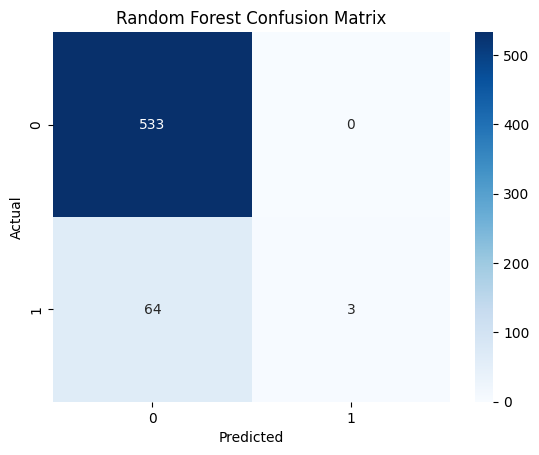

In [69]:
#Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

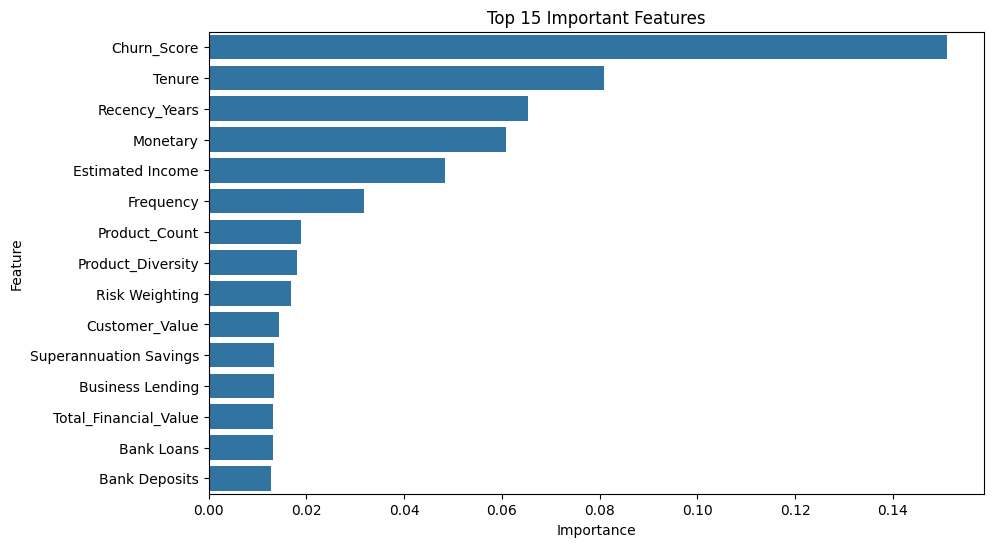

In [70]:
#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.show()